In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
oil = pd.read_csv("Brent Oil.csv")
gold = pd.read_csv("Gold 100years.csv")
silver = pd.read_csv("silver 100 years.csv")

In [4]:
print(oil.head())
print(gold.head())
print(silver.head())

         Date  Value
0  01/01/1946  21.23
1  02/01/1946  21.35
2  03/01/1946  21.11
3  04/01/1946  22.79
4  05/01/1946  22.67
         Date  Value
0  01/01/1915  19.25
1  02/01/1915  19.25
2  03/01/1915  19.25
3  04/01/1915  19.25
4  05/01/1915  19.25
         Date  Value
0  01/01/1915   0.51
1  02/01/1915   0.51
2  03/01/1915   0.51
3  04/01/1915   0.51
4  05/01/1915   0.51


In [5]:
oil['Date'] = pd.to_datetime(oil['Date'], dayfirst=True)
gold['Date'] = pd.to_datetime(gold['Date'], dayfirst=True)
silver['Date'] = pd.to_datetime(silver['Date'], dayfirst=True)

In [6]:
print(oil.info())
print(gold.info())
print(silver.info())

<class 'pandas.DataFrame'>
RangeIndex: 963 entries, 0 to 962
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    963 non-null    datetime64[us]
 1   Value   963 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 15.2 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 1336 entries, 0 to 1335
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1336 non-null   datetime64[us]
 1   Value   1336 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 21.0 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 1336 entries, 0 to 1335
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1336 non-null   datetime64[us]
 1   Value   1336 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 21.0 KB

In [7]:
oil['Date'] = pd.to_datetime(oil['Date'], dayfirst=True)
gold['Date'] = pd.to_datetime(gold['Date'], dayfirst=True)
silver['Date'] = pd.to_datetime(silver['Date'], dayfirst=True)

In [8]:
oil['Year'] = oil['Date'].dt.year
gold['Year'] = gold['Date'].dt.year
silver['Year'] = silver['Date'].dt.year

In [9]:
print(oil.isnull().sum())
print(gold.isnull().sum())
print(silver.isnull().sum())

Date     0
Value    0
Year     0
dtype: int64
Date     0
Value    0
Year     0
dtype: int64
Date     0
Value    0
Year     0
dtype: int64


In [10]:
print(oil.duplicated().sum())
print(gold.duplicated().sum())
print(silver.duplicated().sum())

0
0
0


                                                        PART A; Q: 6-12

6. What were the highest and lowest Brent Oil prices in the dataset, and in which years did they occur? 

In [11]:
highest_oil = oil.loc[oil['Value'].idxmax()]
lowest_oil = oil.loc[oil['Value'].idxmin()]

oil_summary = pd.DataFrame({
    'Type':['Highest','Lowest'],
    'Price':[highest_oil['Value'], lowest_oil['Value']],
    'Year':[highest_oil['Year'], lowest_oil['Year']]
})

oil_summary

,Type,Price,Year
0,Highest,211.21,2008
1,Lowest,21.11,1946


7. What were the highest and lowest Gold prices in the dataset, and in which years did they occur? 

In [12]:
highest_gold = gold.loc[gold['Value'].idxmax()]
lowest_gold = gold.loc[gold['Value'].idxmin()]

gold_summary = pd.DataFrame({
    'Type':['Highest','Lowest'],
    'Price':[highest_gold['Value'], lowest_gold['Value']],
    'Year':[highest_gold['Year'], lowest_gold['Year']]
})

gold_summary

,Type,Price,Year
0,Highest,5277.89,2026
1,Lowest,19.25,1915


8. What were the highest and lowest Silver prices in the dataset, and in which years did they occur? 

In [13]:
highest_silver = silver.loc[silver['Value'].idxmax()]
lowest_silver = silver.loc[silver['Value'].idxmin()]

silver_summary = pd.DataFrame({
    'Type':['Highest','Lowest'],
    'Price':[highest_silver['Value'], lowest_silver['Value']],
    'Year':[highest_silver['Year'], lowest_silver['Year']]
})

silver_summary

,Type,Price,Year
0,Highest,113.9528,2026
1,Lowest,0.2800,1932


9. Calculate the average price by year for Brent Oil, Gold and Silver. 

In [14]:
oil_avg = oil.groupby('Year')['Value'].mean().reset_index()
oil_avg.rename(columns={'Value':'Avg_Brent_Oil'}, inplace=True)

gold_avg = gold.groupby('Year')['Value'].mean().reset_index()
gold_avg.rename(columns={'Value':'Avg_Gold'}, inplace=True)

silver_avg = silver.groupby('Year')['Value'].mean().reset_index()
silver_avg.rename(columns={'Value':'Avg_Silver'}, inplace=True)

annual_avg = pd.merge(oil_avg, gold_avg, on='Year', how='outer')
annual_avg = pd.merge(annual_avg, silver_avg, on='Year', how='outer')

annual_avg = annual_avg.sort_values('Year')

annual_avg

,Year,Avg_Brent_Oil,Avg_Gold,Avg_Silver
0,1915,NaN,19.250000,0.510000
1,1916,NaN,19.470000,0.670000
2,1917,NaN,19.660000,0.840000
3,1918,NaN,19.840000,0.980000
4,1919,NaN,20.030000,1.130000
...,...,...,...,...
107,2022,106.452500,1798.956575,21.671767
108,2023,84.192500,1953.688517,23.579675
109,2024,79.832500,2404.577567,28.128033
110,2025,65.926667,3472.540975,41.501500


The Brent Oil dataset begins in 1946, whereas the Gold and Silver datasets begin in 1915. Therefore, annual average Brent Oil prices are unavailable for the years 1915 TO 1945. These missing values appear as NaN in the combined annual average table and do not represent data quality issues.

10. Which five years had the highest average Brent Oil price? 

In [15]:
top5_oil = oil_avg.sort_values(
    by='Avg_Brent_Oil',
    ascending=False
).head(5)

top5_oil

,Year,Avg_Brent_Oil
62,2008,150.963333
34,1980,149.860000
65,2011,142.115000
67,2013,138.301667
66,2012,135.268333


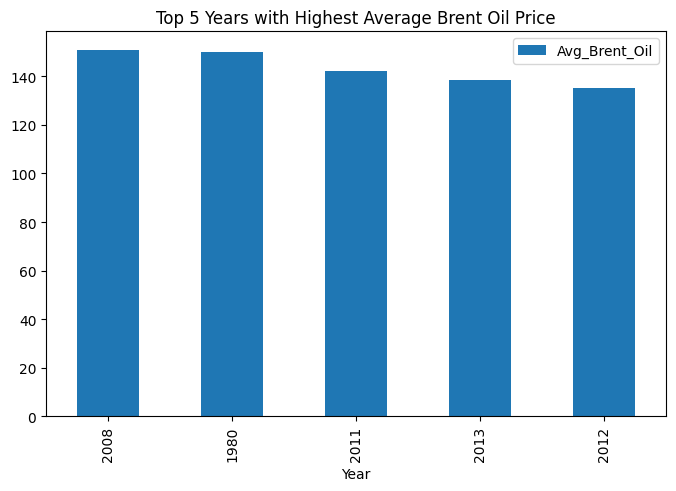

In [16]:
top5_oil.plot(
    x='Year',
    y='Avg_Brent_Oil',
    kind='bar',
    figsize=(8,5),
    title='Top 5 Years with Highest Average Brent Oil Price'
)
plt.show()

11. Which five years had the highest average Gold price? 

In [17]:
top5_gold = gold_avg.sort_values(
    by='Avg_Gold',
    ascending=False
).head(5)

top5_gold

,Year,Avg_Gold
111,2026,4881.619800
110,2025,3472.540975
109,2024,2404.577567
108,2023,1953.688517
107,2022,1798.956575


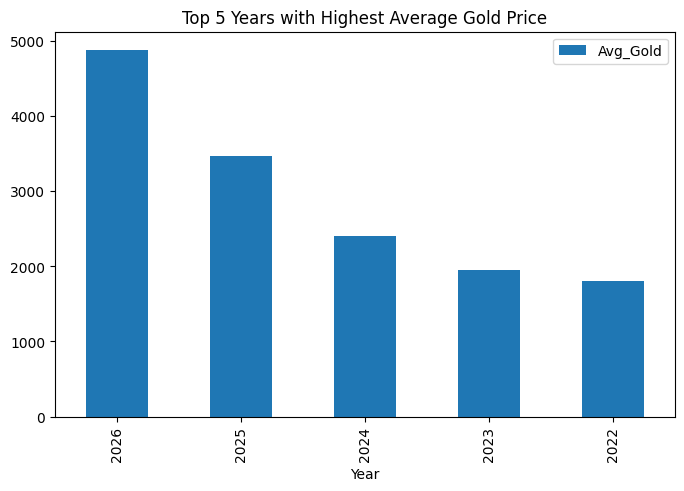

In [18]:
top5_gold.plot(
    x='Year',
    y='Avg_Gold',
    kind='bar',
    figsize=(8,5),
    title='Top 5 Years with Highest Average Gold Price'
)
plt.show()

12. Which five years had the highest average Silver price? 

In [19]:
top5_silver = silver_avg.sort_values(
    by='Avg_Silver',
    ascending=False
).head(5)

top5_silver

,Year,Avg_Silver
111,2026,96.083200
110,2025,41.501500
96,2011,35.556667
97,2012,31.626667
109,2024,28.128033


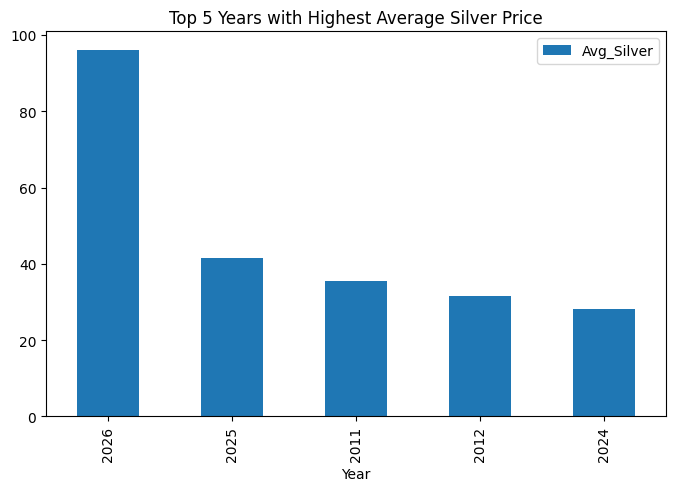

In [20]:
top5_silver.plot(
    x='Year',
    y='Avg_Silver',
    kind='bar',
    figsize=(8,5),
    title='Top 5 Years with Highest Average Silver Price'
)
plt.show()

Brint Oil Price Trend

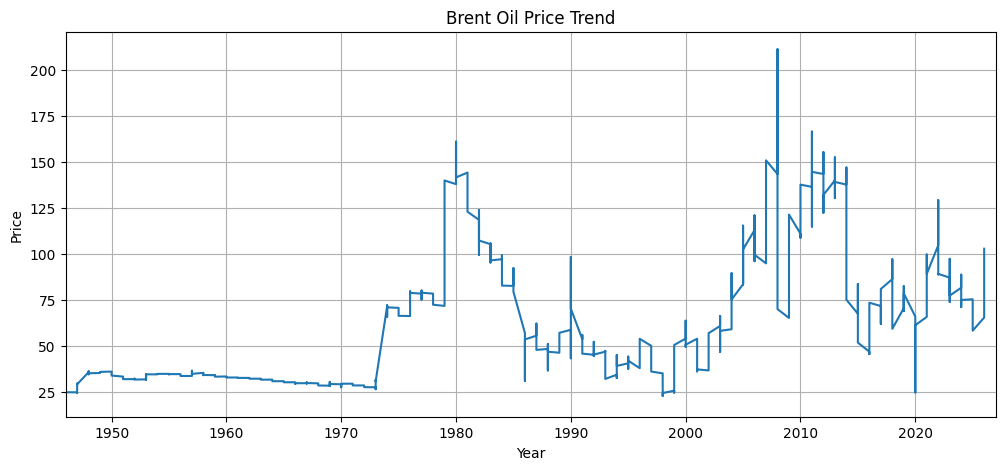

In [21]:
plt.figure(figsize=(12,5))
plt.plot(oil['Year'], oil['Value'])

plt.xlim(oil['Year'].min(), 2027)

plt.title("Brent Oil Price Trend")
plt.xlabel("Year")
plt.ylabel("Price")
plt.grid(True)

plt.show()

Gold Price Trend

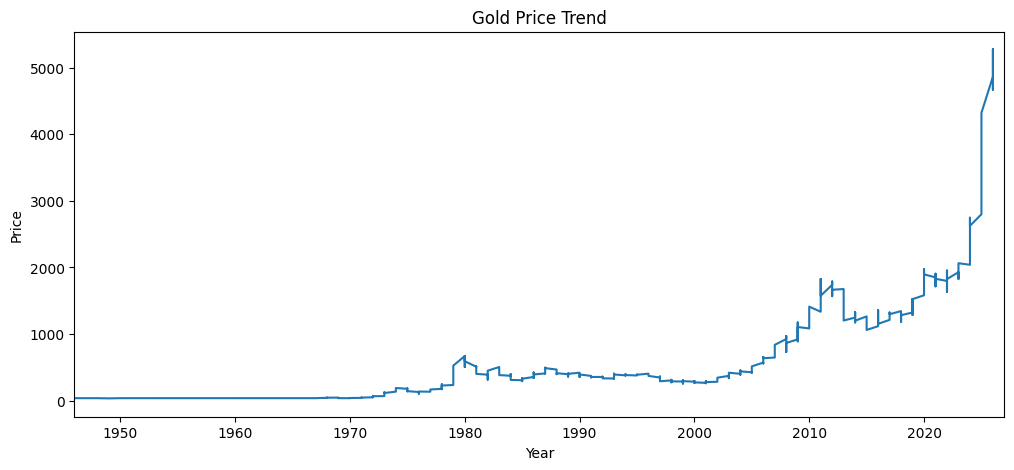

In [22]:
plt.figure(figsize=(12,5))
plt.plot(gold['Year'], gold['Value'])
plt.xlim(oil['Year'].min(), 2027)
plt.title("Gold Price Trend")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()

Silver Price Trend

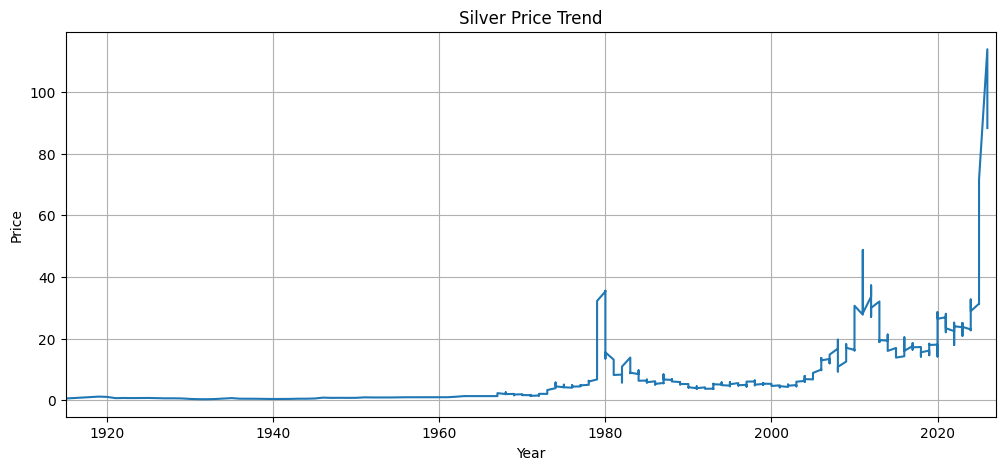

In [23]:
plt.figure(figsize=(12,5))
plt.plot(silver['Year'], silver['Value'])

plt.xlim(silver['Year'].min(), 2027)

plt.title("Silver Price Trend")
plt.xlabel("Year")
plt.ylabel("Price")
plt.grid(True)

plt.show()

                                                            PART B

8. Choose one crisis period and compare the behaviour of Oil, Gold and Silver in that period

In [24]:
oil_avg = oil.groupby('Year')['Value'].mean().reset_index()
oil_avg.rename(columns={'Value':'Avg_Brent_Oil'}, inplace=True)

gold_avg = gold.groupby('Year')['Value'].mean().reset_index()
gold_avg.rename(columns={'Value':'Avg_Gold'}, inplace=True)

silver_avg = silver.groupby('Year')['Value'].mean().reset_index()
silver_avg.rename(columns={'Value':'Avg_Silver'}, inplace=True)

In [25]:
annual_avg = pd.merge(oil_avg, gold_avg, on='Year', how='inner')
annual_avg = pd.merge(annual_avg, silver_avg, on='Year', how='inner')

annual_avg.head()

,Year,Avg_Brent_Oil,Avg_Gold,Avg_Silver
0,1946,22.898333,35.00,0.80
1,1947,27.201667,35.00,0.72
2,1948,35.307500,35.00,0.74
3,1949,35.647500,31.88,0.72
4,1950,35.277500,35.00,0.74


In [26]:
annual_avg['Oil_Change_%'] = annual_avg['Avg_Brent_Oil'].pct_change() * 100

annual_avg['Gold_Change_%'] = annual_avg['Avg_Gold'].pct_change() * 100

annual_avg['Silver_Change_%'] = annual_avg['Avg_Silver'].pct_change() * 100

In [27]:
annual_avg['Crisis_Score'] = (
    annual_avg['Oil_Change_%'].abs() +
    annual_avg['Gold_Change_%'].abs() +
    annual_avg['Silver_Change_%'].abs()
)

In [28]:
top_crisis_years = annual_avg.sort_values(
    by='Crisis_Score',
    ascending=False
)[[
    'Year',
    'Oil_Change_%',
    'Gold_Change_%',
    'Silver_Change_%',
    'Crisis_Score'
]].head(15)

top_crisis_years

,Year,Oil_Change_%,Gold_Change_%,Silver_Change_%,Crisis_Score
28,1974,141.546174,61.753304,83.370859,286.670336
33,1979,34.329995,63.100506,127.735677,225.166179
34,1980,48.306490,89.348859,55.537069,193.192418
80,2026,19.324502,40.577745,131.517415,191.419662
27,1973,2.288153,69.136725,52.626411,124.051290
65,2011,17.396243,27.398605,73.362587,118.157435
60,2006,13.314780,36.206209,60.101466,109.622454
79,2025,-17.418762,44.413764,47.544976,109.377502
75,2021,68.765671,0.452421,20.061422,89.279513
74,2020,-33.550973,26.992511,27.101745,87.645228


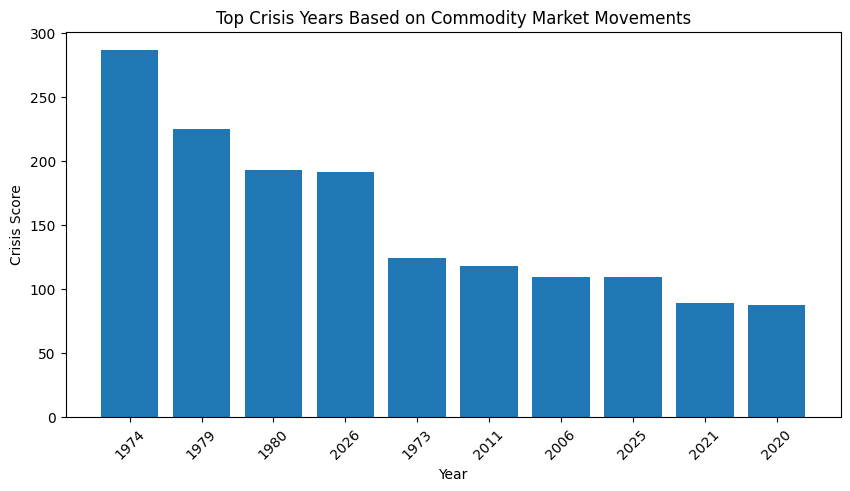

In [29]:
top10 = top_crisis_years.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10['Year'].astype(str),
        top10['Crisis_Score'])

plt.title('Top Crisis Years Based on Commodity Market Movements')
plt.xlabel('Year')
plt.ylabel('Crisis Score')
plt.xticks(rotation=45)

plt.show()

comparison of the crisis between 1974 and 2026

In [30]:
comparison = pd.DataFrame({
    'Commodity':['Brent Oil','Gold','Silver'],
    '1974':[
        oil_avg.loc[oil_avg['Year']==1974,'Avg_Brent_Oil'].values[0],
        gold_avg.loc[gold_avg['Year']==1974,'Avg_Gold'].values[0],
        silver_avg.loc[silver_avg['Year']==1974,'Avg_Silver'].values[0]
    ],
    '2026':[
        oil_avg.loc[oil_avg['Year']==2026,'Avg_Brent_Oil'].values[0],
        gold_avg.loc[gold_avg['Year']==2026,'Avg_Gold'].values[0],
        silver_avg.loc[silver_avg['Year']==2026,'Avg_Silver'].values[0]
    ]
})

comparison

,Commodity,1974,2026
0,Brent Oil,69.466667,78.666667
1,Gold,161.679167,4881.619800
2,Silver,4.750833,96.083200


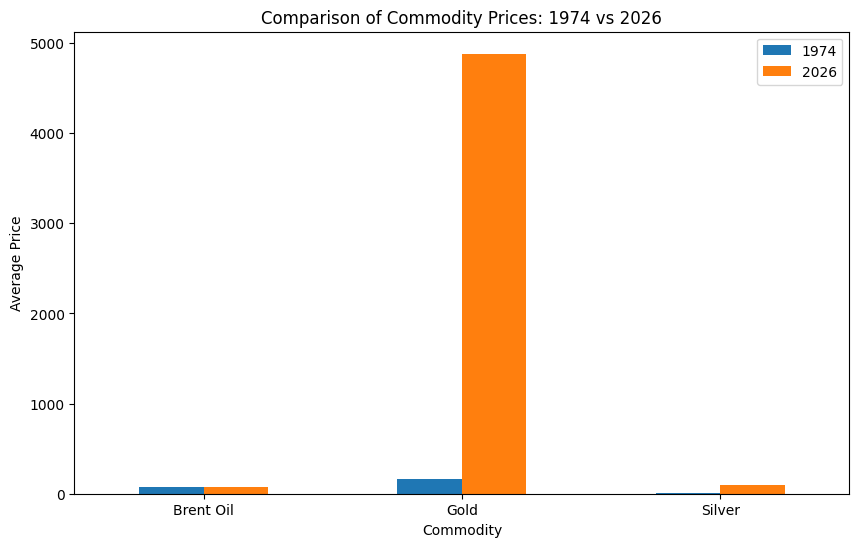

In [31]:
comparison.set_index('Commodity').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Comparison of Commodity Prices: 1974 vs 2026')
plt.ylabel('Average Price')
plt.xlabel('Commodity')
plt.xticks(rotation=0)

plt.show()

In [32]:
crisis_compare = annual_avg[
    annual_avg['Year'].isin([1974, 2026])
][[
    'Year',
    'Oil_Change_%',
    'Gold_Change_%',
    'Silver_Change_%',
    'Crisis_Score'
]]

crisis_compare

,Year,Oil_Change_%,Gold_Change_%,Silver_Change_%,Crisis_Score
28,1974,141.546174,61.753304,83.370859,286.670336
80,2026,19.324502,40.577745,131.517415,191.419662


Although commodity prices were significantly higher in 2026 than in 1974, the Crisis Score is based on annual percentage changes rather than absolute price levels. The 1974 Oil Crisis produced larger simultaneous increases across Oil, Gold and Silver, resulting in a higher Crisis Score. Inflation and long-term market growth explain why the absolute prices in 2026 are much higher, but they do not necessarily indicate a larger year-to-year market shock.

                                                        1974 crisis period

In [33]:
comparison_1974 = pd.DataFrame({
    'Commodity':['Brent Oil','Gold','Silver'],
    'Average Price':[
        oil_avg.loc[oil_avg['Year']==1974,'Avg_Brent_Oil'].values[0],
        gold_avg.loc[gold_avg['Year']==1974,'Avg_Gold'].values[0],
        silver_avg.loc[silver_avg['Year']==1974,'Avg_Silver'].values[0]
    ]
})

comparison_1974

,Commodity,Average Price
0,Brent Oil,69.466667
1,Gold,161.679167
2,Silver,4.750833


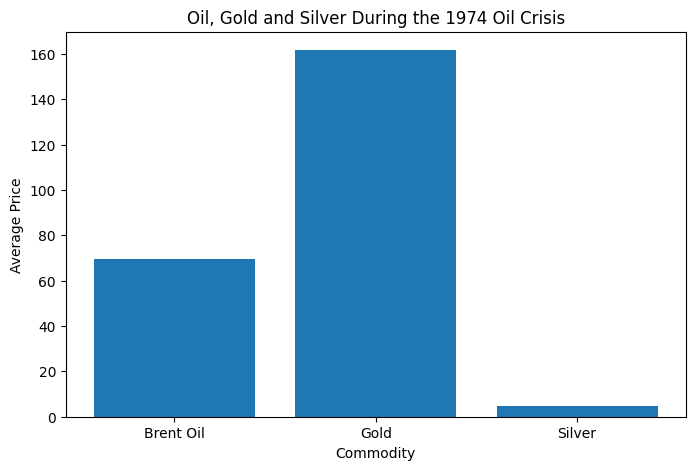

In [34]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_1974['Commodity'],
    comparison_1974['Average Price']
)

plt.title('Oil, Gold and Silver During the 1974 Oil Crisis')
plt.xlabel('Commodity')
plt.ylabel('Average Price')

plt.show()

The year 1974 was selected for crisis analysis because it recorded the highest combined commodity market movement, with a Crisis Score of 286.67. This period corresponds to the 1973–1974 Oil Crisis, during which oil-exporting countries imposed supply restrictions that significantly disrupted global energy markets. Brent Oil recorded the largest increase, reflecting supply shortages and rising energy costs. Gold prices also increased substantially as investors sought safe-haven assets during economic uncertainty and inflationary pressures. Silver prices rose as well, influenced by both investment demand and commodity market speculation. The results indicate that geopolitical disruptions can simultaneously affect multiple commodity markets, although the magnitude of the impact differs across commodities.

                                                        1973 Oil Crisis
                                                        
The 1973 Oil Crisis, often called the first oil shock, was a global energy and economic crisis triggered by the Arab-led oil embargo during the 1973 Yom Kippur War. It demonstrated the geopolitical power of oil-exporting states and exposed the heavy dependence of industrialized economies on imported petroleum. Oil prices surged dramatically, contributing to inflation, recession, and major changes in energy policy around the world. 

                                                    Background and Causes
                                                        
The crisis began in October 1973 after Egypt and Syria launched the Yom Kippur War against Israel. In response to U.S. and other Western support for Israel, members of the Organization of Arab Petroleum Exporting Countries (OAPEC)—closely associated with, but distinct from, OPEC—announced production cuts and embargoes against selected countries. The embargo was intended to pressure governments to change their Middle East policies while also strengthening producer control over oil markets. 

                                                        What Happened
                                                            
OAPEC announced the embargo on October 17, 1973. Oil exports to the United States and several other countries were reduced or halted, while production cuts further tightened global supply. The embargo lasted until March 1974, but oil prices rose from roughly $3 per barrel to around $12 per barrel, transforming the economics of energy worldwide. 

                                                  Economic and Social Impact
                                                        
The sudden increase in energy costs produced fuel shortages, long lines at gasoline stations, and widespread public anxiety. Many economies experienced a combination of high inflation and slow growth—later known as stagflation. Stock markets weakened, consumer costs rose, and governments faced difficult choices between controlling inflation and supporting economic growth. 

                                                        Long-Term Significance
                                                        
The crisis reshaped global energy policy. Many countries created strategic petroleum reserves, invested in energy efficiency, diversified energy supplies, and reduced dependence on imported oil. The event also elevated OPEC and OAPEC as major geopolitical actors and led to the creation of the International Energy Agency (IEA) in 1974 to coordinate responses to future supply disruptions. The 1973 Oil Crisis remains one of the most influential economic shocks of the twentieth century. 

                                                        Historical Legacy
Historians view the crisis as more than an energy shortage. It marked a turning point in international politics, demonstrated how natural resources could be used as strategic leverage, and helped end the era of inexpensive oil that had characterized much of the post–World War II economic boom. Its effects influenced economic policy, transportation, industrial planning, and foreign relations for decades afterward.

https://www.energypolicy.columbia.edu/publications/the-1973-oil-crisis-three-crises-in-one-and-the-lessons-for-today/

13. From your analysis, which market looks most sensitive to global events: Oil, Gold, Silver or currencies?



In [35]:
currency = pd.read_csv("swift_currency_tracker_all_reports.csv")

In [36]:
print(currency.head())

   report_month     data_month source_report_name                metric  \
0  January 2026  December 2025        RMB Tracker  Global Payment Share   
1  January 2026  December 2025        RMB Tracker  Global Payment Share   
2  January 2026  December 2025        RMB Tracker  Global Payment Share   
3  January 2026  December 2025        RMB Tracker  Global Payment Share   
4  January 2026  December 2025        RMB Tracker  Global Payment Share   

           category currency_or_economy  value unit  rmb_global_rank   notes  
0  Currency Ranking                 USD  50.49    %              NaN  Rank 1  
1  Currency Ranking                 EUR  21.90    %              NaN  Rank 2  
2  Currency Ranking                 GBP   6.73    %              NaN  Rank 3  
3  Currency Ranking                 CAD   3.44    %              NaN  Rank 4  
4  Currency Ranking                 JPY   3.42    %              NaN  Rank 5  


In [37]:
print(currency.columns)

Index(['report_month', 'data_month', 'source_report_name', 'metric',
       'category', 'currency_or_economy', 'value', 'unit', 'rmb_global_rank',
       'notes'],
      dtype='str')


In [38]:
currency['currency_or_economy'].unique()

<StringArray>
[           'USD',            'EUR',            'GBP',            'CAD',
            'JPY',            'CNY',            'HKD',            'AUD',
            'SGD',            'CHF',            'SEK',            'PLN',
            'NOK',            'DKK',            'NZD',            'MXN',
            'ZAR',            'THB',            'HUF',            'MYR',
            'CZK',            'TRY',            'ALL',      'Hong Kong',
 'United Kingdom',      'Singapore',  'United States',         'France',
         'Taiwan',    'South Korea',      'Australia',          'Japan',
        'Germany',          'Macao',        'Belgium',     'Luxembourg',
    'Netherlands',         'Canada',            'SAR',            'AED',
            'IDR',            'VND',            'KRW',          'China',
         'Others',            'CLP',            'INR',            'KWD']
Length: 48, dtype: str

In [39]:
currency['metric'].unique()

<StringArray>
[                     'Global Payment Share',
 'International Payment Share (ex-Eurozone)',
                    'RMB MoM Payment Growth',
         'All Currencies MoM Payment Growth',
                   'Offshore RMB by Economy',
                       'Trade Finance Share',
                  'FX Spot Currency Ranking',
                   'FX Spot Economies (RMB)']
Length: 8, dtype: str

In [40]:
currency_gp = currency[
    currency['metric'] == 'Global Payment Share'
].copy()

In [41]:
currency_gp['data_month'] = pd.to_datetime(
    currency_gp['data_month']
)

/var/folders/_0/048r08px7fx7x8j424rwy8v40000gn/T/ipykernel_1239/3630622781.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  currency_gp['data_month'] = pd.to_datetime(


In [42]:
currency_market = (
    currency_gp.groupby('data_month')['value']
    .mean()
    .reset_index()
)

currency_market.head()

,data_month,value
0,2025-12-01,4.9130
1,2026-01-01,4.9175
2,2026-02-01,4.9160
3,2026-03-01,4.9170


In [43]:
currency_market['Currency_Change_%'] = (
    currency_market['value'].pct_change() * 100
)

In [44]:
currency_volatility = (
    currency_market['Currency_Change_%']
    .dropna()
    .std()
)

print(currency_volatility)

0.06133208890297762


In [45]:
oil_volatility = annual_avg['Oil_Change_%'].std()

gold_volatility = annual_avg['Gold_Change_%'].std()

silver_volatility = annual_avg['Silver_Change_%'].std()

In [46]:
volatility_table = pd.DataFrame({
    'Market': [
        'Oil',
        'Gold',
        'Silver',
        'Currencies'
    ],
    'Volatility': [
        oil_volatility,
        gold_volatility,
        silver_volatility,
        currency_volatility
    ]
})

volatility_table = volatility_table.sort_values(
    by='Volatility',
    ascending=False
)

volatility_table

,Market,Volatility
2,Silver,29.786524
0,Oil,25.163561
1,Gold,20.417405
3,Currencies,0.061332


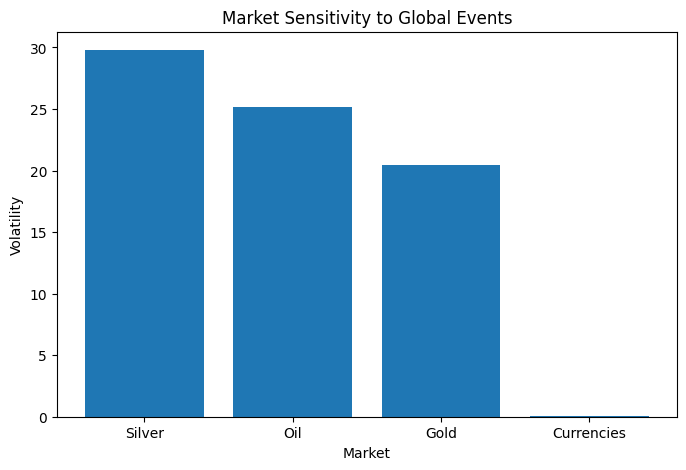

In [47]:
plt.figure(figsize=(8,5))

plt.bar(
    volatility_table['Market'],
    volatility_table['Volatility']
)

plt.title('Market Sensitivity to Global Events')
plt.xlabel('Market')
plt.ylabel('Volatility')

plt.show()

Currency market sensitivity was measured using monthly percentage changes in Global Payment Share data, while commodity sensitivity was measured using annual percentage changes in average prices. Volatility (standard deviation of percentage changes) was used as a common indicator of market sensitivity.

To determine which market is most sensitive to global events, historical data for Brent Oil, Gold, Silver, and currencies were analyzed. First, the commodity datasets were cleaned and annual average prices were calculated. Year-over-year percentage changes were then computed for each commodity to measure how strongly prices fluctuated over time. For the currency dataset, the Global Payment Share metric was selected and monthly percentage changes were calculated to capture movements in the currency market. Volatility was measured using the standard deviation of percentage changes, as higher volatility indicates greater sensitivity to market events. Finally, the volatility values of Oil, Gold, Silver, and the overall Currency market were compared using a summary table and bar chart. The market with the highest volatility was identified as the most sensitive to global economic and geopolitical events.

In [48]:
currency_gp = currency[
    currency['metric'] == 'Global Payment Share'
].copy()

In [49]:
currency_gp['data_month'] = pd.to_datetime(currency_gp['data_month'])

currency_gp['Year'] = currency_gp['data_month'].dt.year

/var/folders/_0/048r08px7fx7x8j424rwy8v40000gn/T/ipykernel_1239/2693858442.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  currency_gp['data_month'] = pd.to_datetime(currency_gp['data_month'])


In [51]:
currency_annual = (
    currency_gp.groupby('Year')['value']
    .mean()
    .reset_index()
)

currency_annual.head()

,Year,value
0,2025,4.913000
1,2026,4.916833


In [54]:
currency_annual['Currency_Change_%'] = (
    currency_annual['value'].pct_change() * 100
)

currency_annual.head()

,Year,value,Currency_Change_%
0,2025,4.913000,NaN
1,2026,4.916833,0.078024


In [55]:
currency_volatility = (
    currency_annual['Currency_Change_%']
    .dropna()
    .std()
)

print("Currency Volatility:", currency_volatility)

Currency Volatility: nan


In [56]:
oil_volatility = annual_avg['Oil_Change_%'].std()

gold_volatility = annual_avg['Gold_Change_%'].std()

silver_volatility = annual_avg['Silver_Change_%'].std()

In [57]:
volatility_table = pd.DataFrame({
    'Market': [
        'Oil',
        'Gold',
        'Silver',
        'Currencies'
    ],
    'Volatility': [
        oil_volatility,
        gold_volatility,
        silver_volatility,
        currency_volatility
    ]
})

volatility_table = volatility_table.sort_values(
    by='Volatility',
    ascending=False
)

volatility_table

,Market,Volatility
2,Silver,29.786524
0,Oil,25.163561
1,Gold,20.417405
3,Currencies,NaN


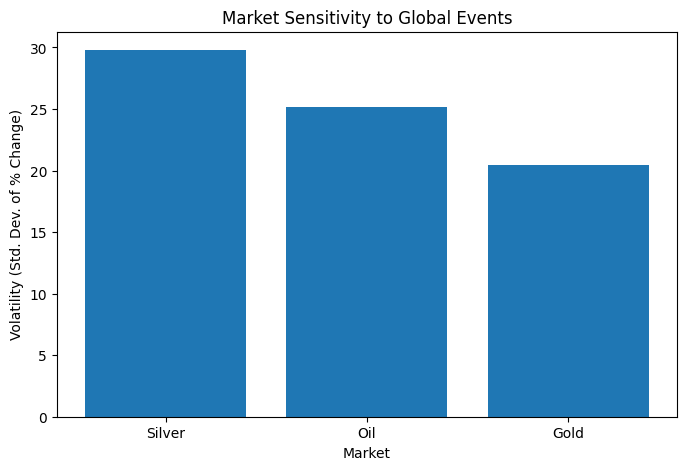

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    volatility_table['Market'],
    volatility_table['Volatility']
)

plt.title('Market Sensitivity to Global Events')
plt.xlabel('Market')
plt.ylabel('Volatility (Std. Dev. of % Change)')

plt.show()

 The volatility analysis shows that Silver was the most sensitive market, followed by Oil and Gold. Silver recorded the highest volatility (29.79), indicating that its prices experienced the largest fluctuations in response to market events. Oil also showed substantial volatility (25.16), reflecting its sensitivity to geopolitical tensions, energy supply disruptions and global economic conditions. Gold exhibited lower volatility (20.42), which is consistent with its role as a relatively stable safe-haven asset. The currency dataset did not produce a valid volatility value because the available data covered a limited time period and did not provide sufficient observations for a reliable standard deviation calculation. Therefore, the comparison of market sensitivity was primarily based on the commodity markets.

16. Give three practical recommendations for investors, companies or policymakers based on your findings.

Recommendation 1 - Investors should diversify their portfolios across multiple asset classes rather than relying on a single commodity. Since Silver and Oil exhibited the highest volatility, they may offer higher return opportunities but also carry greater risk. Gold can be included as a relatively stable asset to help reduce overall portfolio risk during periods of market uncertainty.

Recommendation 2 - Companies that depend heavily on energy and raw materials should implement risk management strategies such as long-term supply contracts or hedging. The analysis showed that Oil prices are highly sensitive to geopolitical events and supply disruptions, which can significantly increase operating costs and affect profitability.

Recommendation 3 - Policymakers should strengthen energy security and maintain strategic reserves to reduce the impact of future global crises. Since commodity markets, particularly Oil and Silver, respond strongly to geopolitical and economic shocks, proactive policies can help stabilize markets, control inflationary pressures and support economic growth during periods of uncertainty.

Conclusion - The analysis indicates that Silver and Oil are the most sensitive commodity markets to global events, while Gold demonstrates relatively lower volatility due to its safe-haven characteristics. These findings highlight the importance of diversification, risk management and proactive policy measures in navigating periods of economic and geopolitical uncertainty.